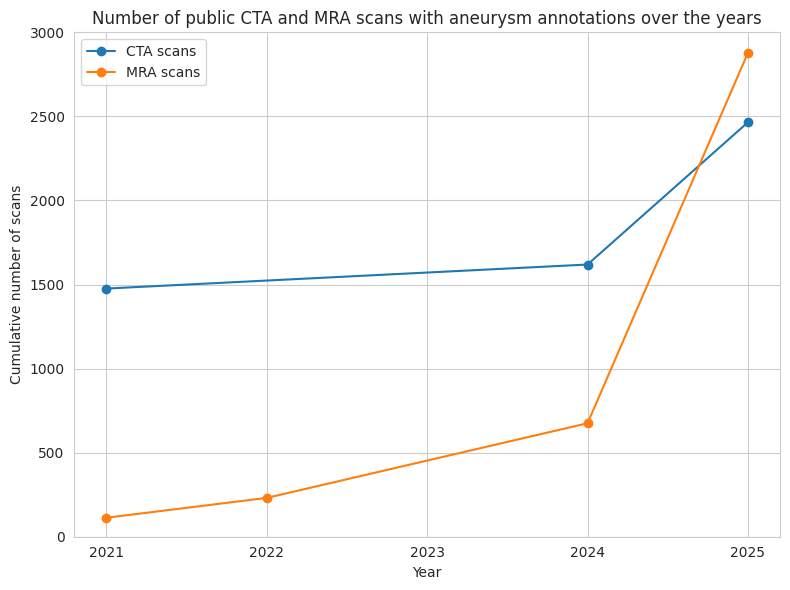

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 



years = [2021, 2024, 2025]

ctas = [1186+152+138, 1186+152+138+143, 1186+152+138+143+846]

years_mras = [2021, 2022, 2024, 2025]
mras = [113, 113+118, 113+118+284+160, 113+118+284+160+2203]

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

plt.plot(years, ctas, marker='o', label='CTA scans')
plt.plot(years_mras, mras, marker='o', label='MRA scans')
plt.title('Number of public CTA and MRA scans with aneurysm annotations over the years')
plt.xlabel('Year')
plt.ylabel('Cumulative number of scans')
plt.xticks(np.arange(2021, 2026, 1))
#set yrange
plt.ylim(0, 3000)
plt.legend()
plt.tight_layout()

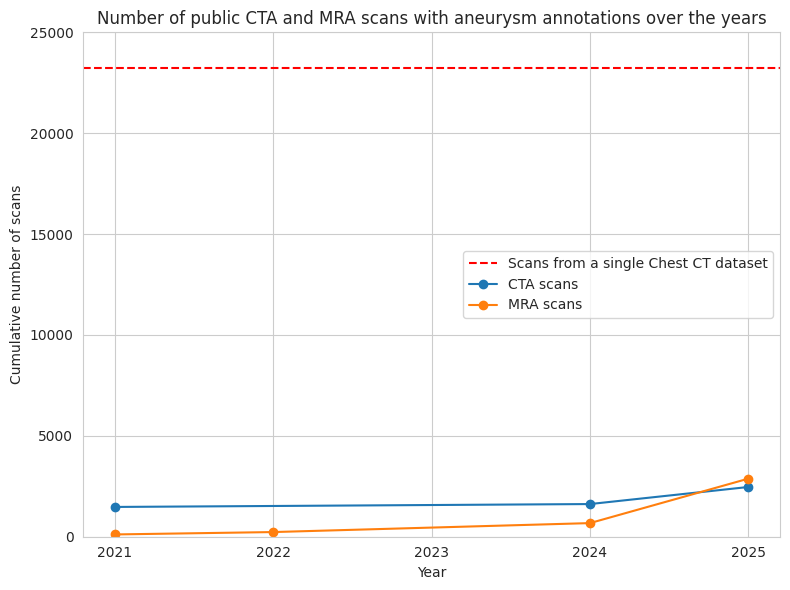

In [18]:


# draw horizontal line at 23248


plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

plt.axhline(y=23248, color='r', linestyle='--', label='Scans from a single Chest CT dataset')
plt.plot(years, ctas, marker='o', label='CTA scans')
plt.plot(years_mras, mras, marker='o', label='MRA scans')
plt.title('Number of public CTA and MRA scans with aneurysm annotations over the years')
plt.xlabel('Year')
plt.ylabel('Cumulative number of scans')
plt.xticks(np.arange(2021, 2026, 1))
#set yrange
plt.ylim(0, 25000)
plt.legend()
plt.tight_layout()

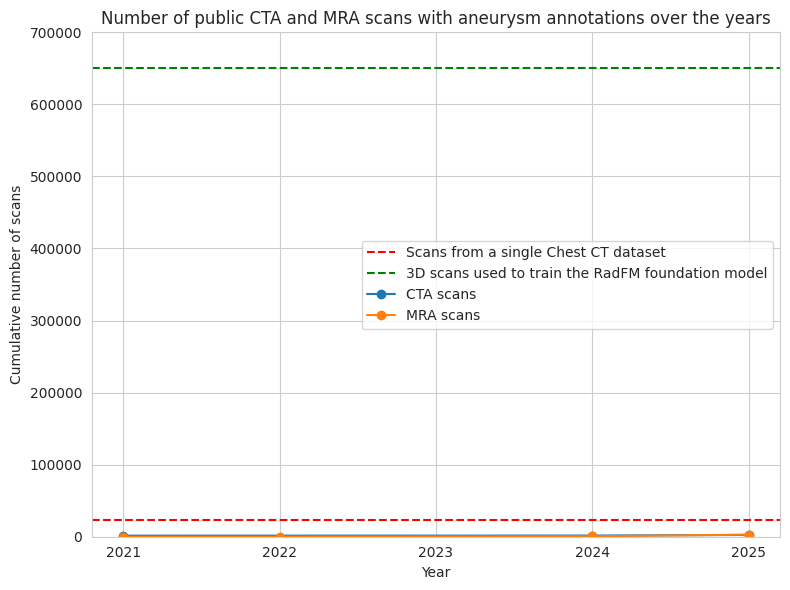

In [19]:


# draw horizontal line at 23248


plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

plt.axhline(y=23248, color='r', linestyle='--', label='Scans from a single Chest CT dataset')
# draw horizontal line at 650000
plt.axhline(y=650000, color='g', linestyle='--', label='3D scans used to train the RadFM foundation model')
plt.plot(years, ctas, marker='o', label='CTA scans')
plt.plot(years_mras, mras, marker='o', label='MRA scans')
plt.title('Number of public CTA and MRA scans with aneurysm annotations over the years')
plt.xlabel('Year')
plt.ylabel('Cumulative number of scans')
plt.xticks(np.arange(2021, 2026, 1))
#set yrange
plt.ylim(0, 700000)
plt.legend()
plt.tight_layout()

6


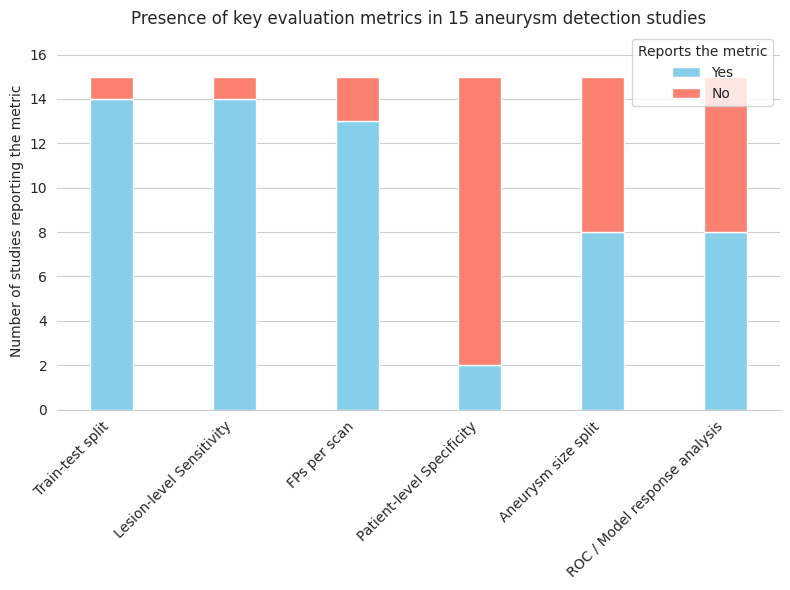

In [50]:
labels = [
    "Train-test split",
    "Lesion-level Sensitivity",
    "FPs per scan",
    "Patient-level Specificity",
    "Aneurysm size split",
    "ROC / Model response analysis"
]
total = 15


roc = [
    1,
    0,
    1,
    0,
    1,
    1,
    0,
    0,
    1,
    1,
    0,
    0,
    0,
    1,
    1,


]

roc = np.sum(roc)
yes = [
    14,
    14,
    
    13,
    2,
    8,
    roc
]
no = [total - y for y in yes]

x = np.arange(len(labels))
print(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 6))
# use stacked bars for yes and no,  do blue for yes and red for no 

ax.bar(x, yes, width, label='Yes', color='skyblue')
ax.bar(x, no, width, bottom=yes, label='No', color='salmon')
ax.set_ylabel('Number of studies reporting the metric')
ax.set_title('Presence of key evaluation metrics in 15 aneurysm detection studies')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
# remove vertical gridlines 



sns.despine()
# remove vertical tick lines 
sns.despine(left=True)

ax.grid(False, axis='x')
# place legend on top right

ax.legend(title="Reports the metric", loc='upper right')
ax.set_ylim(0, 17)
plt.tight_layout()


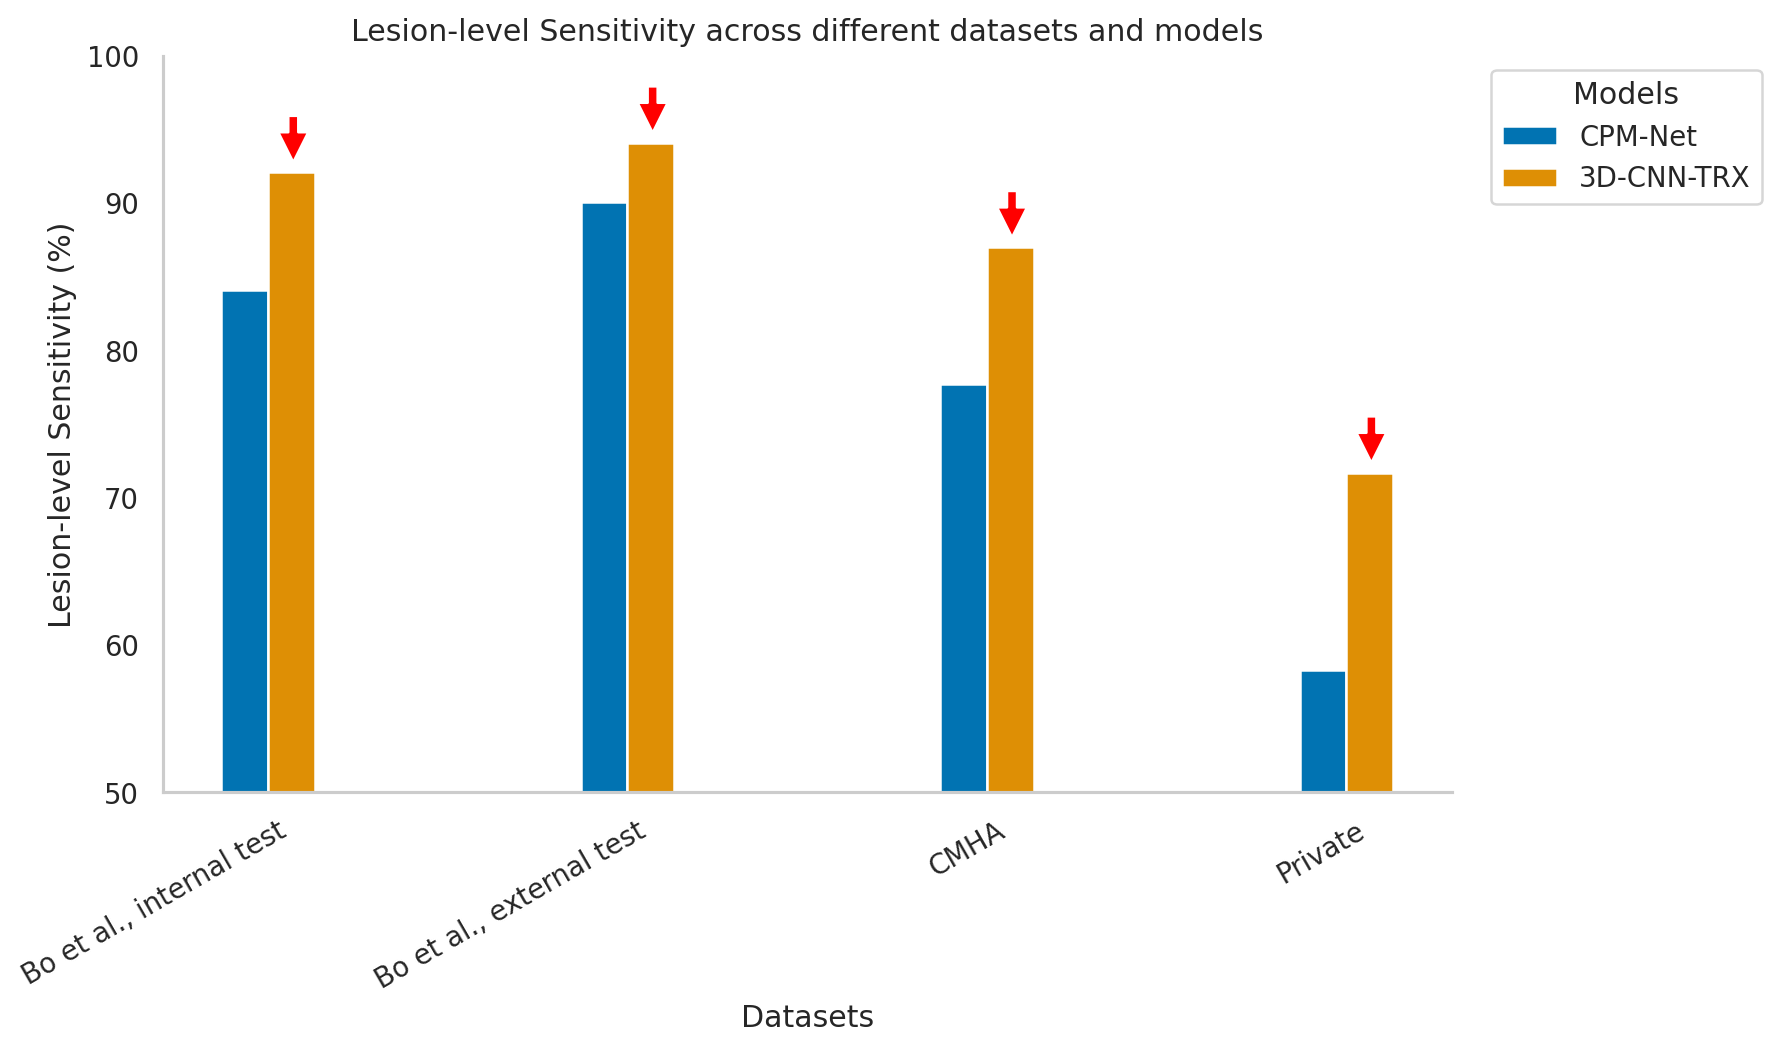

In [106]:
# set font to Century Gothic 
#plt.rcParams["font.family"] = "Gulasch"
import matplotlib.pyplot as plt 
sns.set_style("whitegrid")
datasets = ["Bo et al., internal test", "Bo et al., external test", "CMHA", "Private"]
#colorblind palette 
sns.set_palette("colorblind")
models = ["CPM-Net", 
          "3D-CNN-TRX", 
          "Pre-trained 3D-TRX", 
          "Post-processed\n3D-CNN-TRX", 
          "FP-enhanced\n3D-CNN-TRX", 
          "FP+GT-enhanced\n3D-CNN-TRX"]

# set dejavu sans font 
plt.rcParams["font.family"] = "DejaVu Sans"
sens = [
    [84.1,90.1,77.7,58.3],
    [92.1,94.1,87.0,71.7],
    [92.9,96.0,92.0,78.3],
    [93.7,98.0,89.0,75.5],
    [92.9,97.0,92.0,80.2],
    [93.7,98.0,91.0,84.0]
]

models_to_use = [0, 1]

models = [models[i] for i in models_to_use]
sens = [sens[i] for i in models_to_use]


fig, ax = plt.subplots(figsize=(10, 6), dpi=180)
for i, model in enumerate(models):
    # draw bars 
    ax.bar(np.array(range(len(datasets))) + i*0.13, sens[i], width=0.13, label=model)
ax.set_xlabel('Datasets')
ax.set_ylabel('Lesion-level Sensitivity (%)')
ax.set_title('Lesion-level Sensitivity across different datasets and models')
# make sure legend is outside image 
# rotate xlabels


ax.legend(title="Models", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticks(np.array(range(len(datasets))) + 0.13*len(models)/2)
ax.set_xticklabels(datasets)
ax.set_xticklabels(datasets, rotation=30, ha='right')

# draw red arrow on top of each rightmost bar
for i in range(len(datasets)):
    ax.annotate('', xy=(i + 0.13*len(models) - 0.125, sens[-1][i] + 0.5), xytext=(i + 0.13*len(models) - 0.125, sens[-1][i] + 4),
                arrowprops=dict(facecolor='red', shrink=0.05))

#  remove vertical gridlines
ax.grid(False, axis='x')
ax.grid(False, axis='y')
# remove topmost horizontal gridline

# 

# despine top and right
sns.despine(top=True, right=True)

# don't use lines 
plt.ylim(50, 100)
plt.tight_layout()


In [71]:
from matplotlib.font_manager import get_font_names

print(get_font_names())

['C059', 'DejaVu Serif', 'STIXSizeThreeSym', 'cmss10', 'DejaVu Sans', 'URW Gothic', 'STIXGeneral', 'cmmi10', 'P052', 'Nimbus Roman', 'STIXSizeFourSym', 'Z003', 'Nimbus Mono PS', 'cmb10', 'DejaVu Sans Mono', 'DejaVu Sans Display', 'cmtt10', 'STIXSizeTwoSym', 'D050000L', 'Nimbus Sans', 'URW Bookman', 'DejaVu Serif Display', 'STIX Math', 'STIXNonUnicode', 'Nimbus Sans Narrow', 'cmr10', 'cmsy10', 'cmex10', 'STIXSizeFiveSym', 'STIXSizeOneSym', 'STIX']


Text(0.5, 1.0, "False positive locations for our 3D-CNN-TRX model\nTrained on Bo's dataset, tested on our Private dataset")

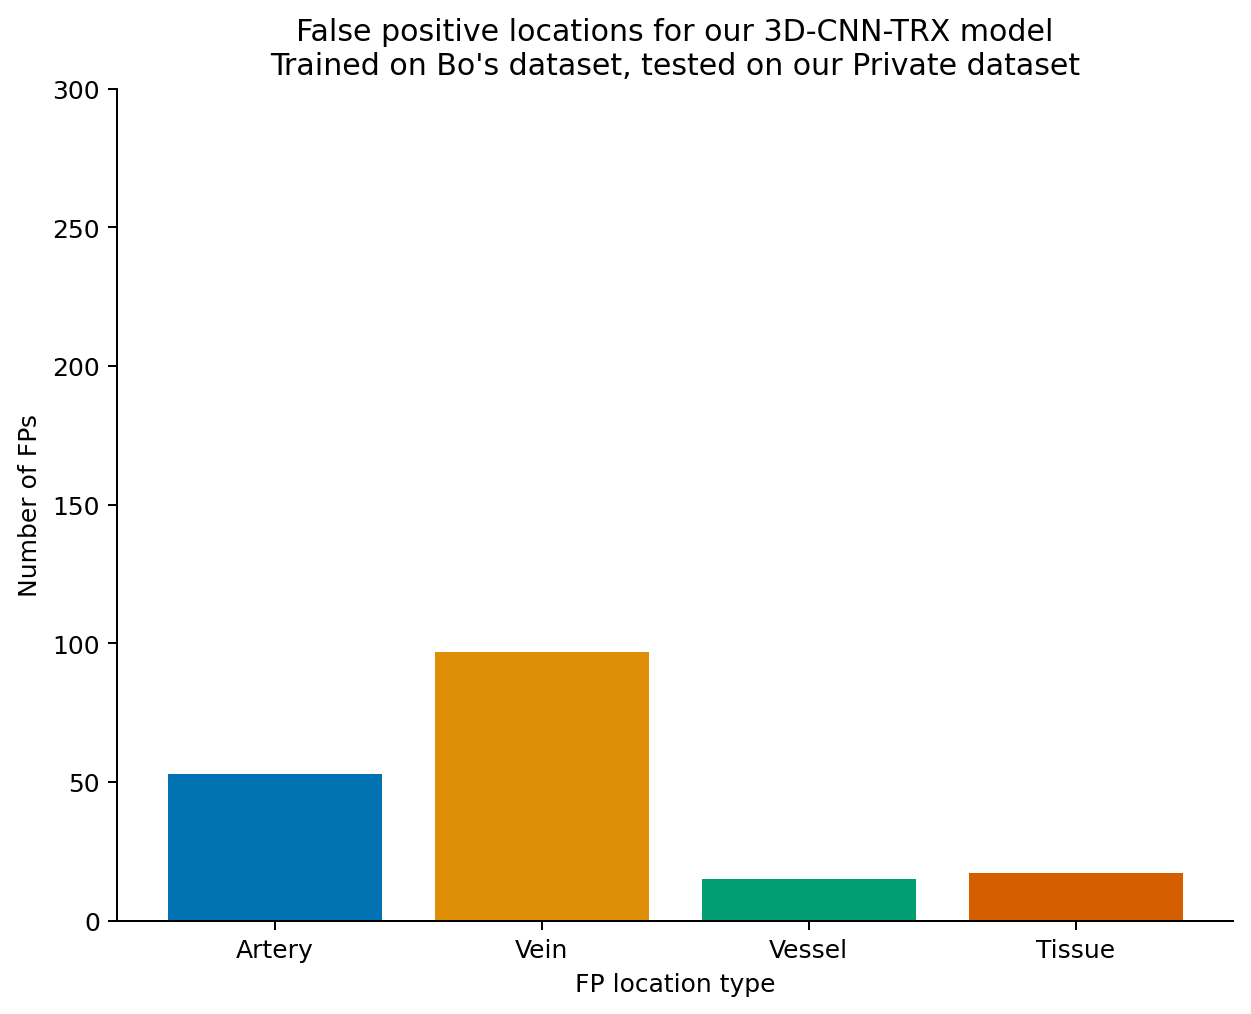

In [3]:
# draw bars  for location
import seaborn as sns 
import matplotlib.pyplot as plt
location = [
    "Artery",
    "Vein",
    "Vessel",
    "Tissue",
]

vals_loc = [
    53,
    97,
    15,
    17
]

general_loc = ["Intracranial", "Extracranial"]

vals_gloc = [105, 77]
sns.set_palette("colorblind")

fig, ax = plt.subplots(figsize=(8, 6), dpi=180)
for i, loc in enumerate(location):
    ax.bar(loc, vals_loc[i])
ax.set_ylim(0, 300)
#remove g rid 
ax.grid(False, axis='x')
ax.grid(False, axis='y')
sns.despine(top=True, right=True)
ax.set_xlabel('FP location type')
ax.set_ylabel('Number of FPs')
ax.set_title('False positive locations for our 3D-CNN-TRX model\nTrained on Bo\'s dataset, tested on our Private dataset')
# remove top and right spines

Text(0.5, 1.0, 'False positive locations for our 3D-CNN-TRX model')

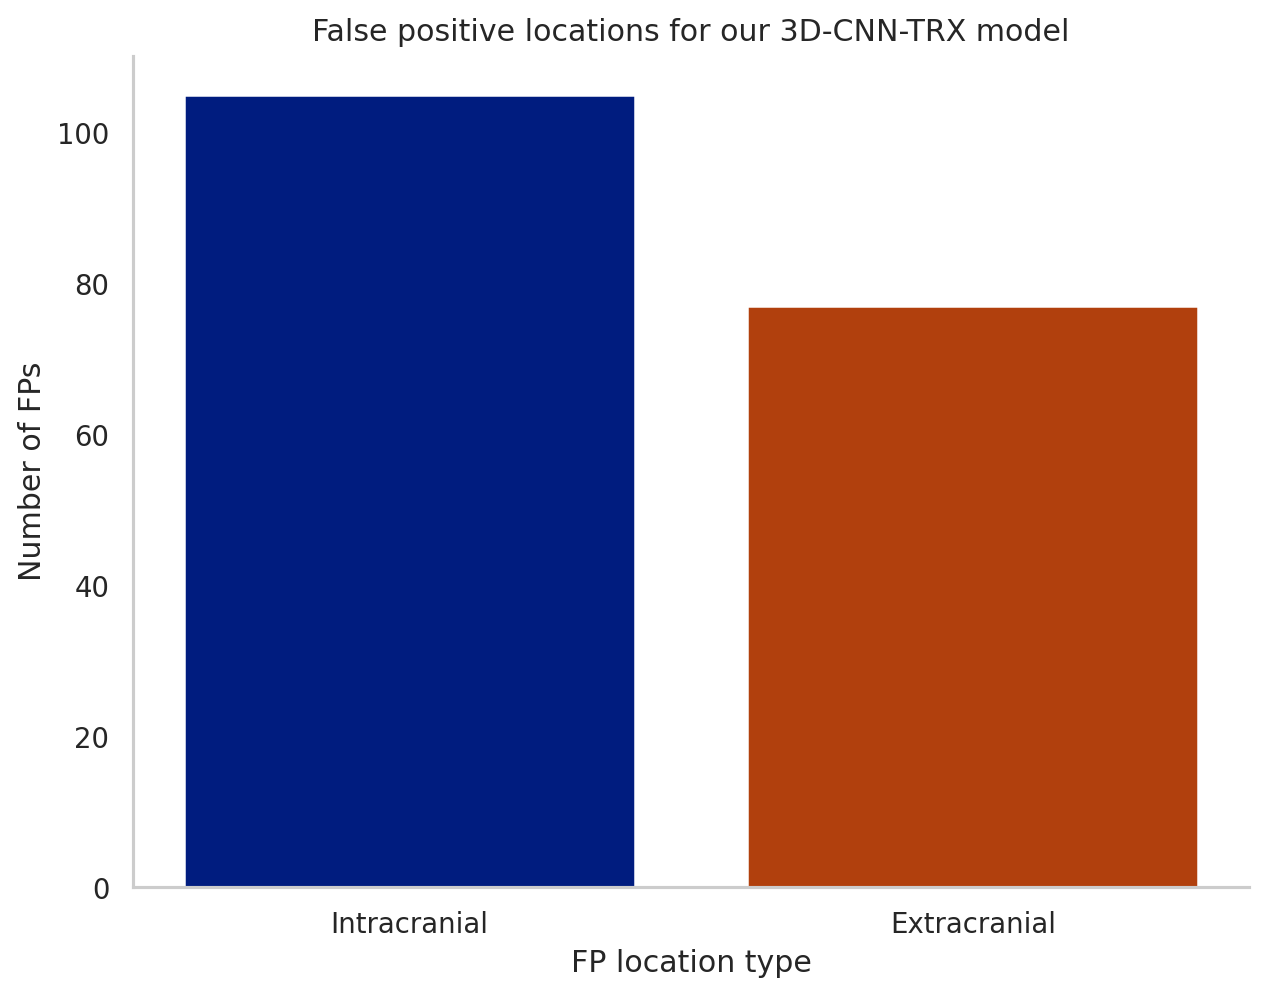

In [122]:
# draw bars  for location
sns.set_palette("dark")

fig, ax = plt.subplots(figsize=(8, 6), dpi=180)
for i, loc in enumerate(general_loc):
    ax.bar(loc, vals_gloc[i])

#remove g rid 
ax.grid(False, axis='x')
ax.grid(False, axis='y')
sns.despine(top=True, right=True)
ax.set_xlabel('FP location type')
ax.set_ylabel('Number of FPs')
ax.set_title('False positive locations for our 3D-CNN-TRX model')
# remove top and right spines

Text(0.5, 1.0, "False positive locations for our 3D-CNN-TRX model\nTrained on Bo's dataset, tested on the RSNA dataset")

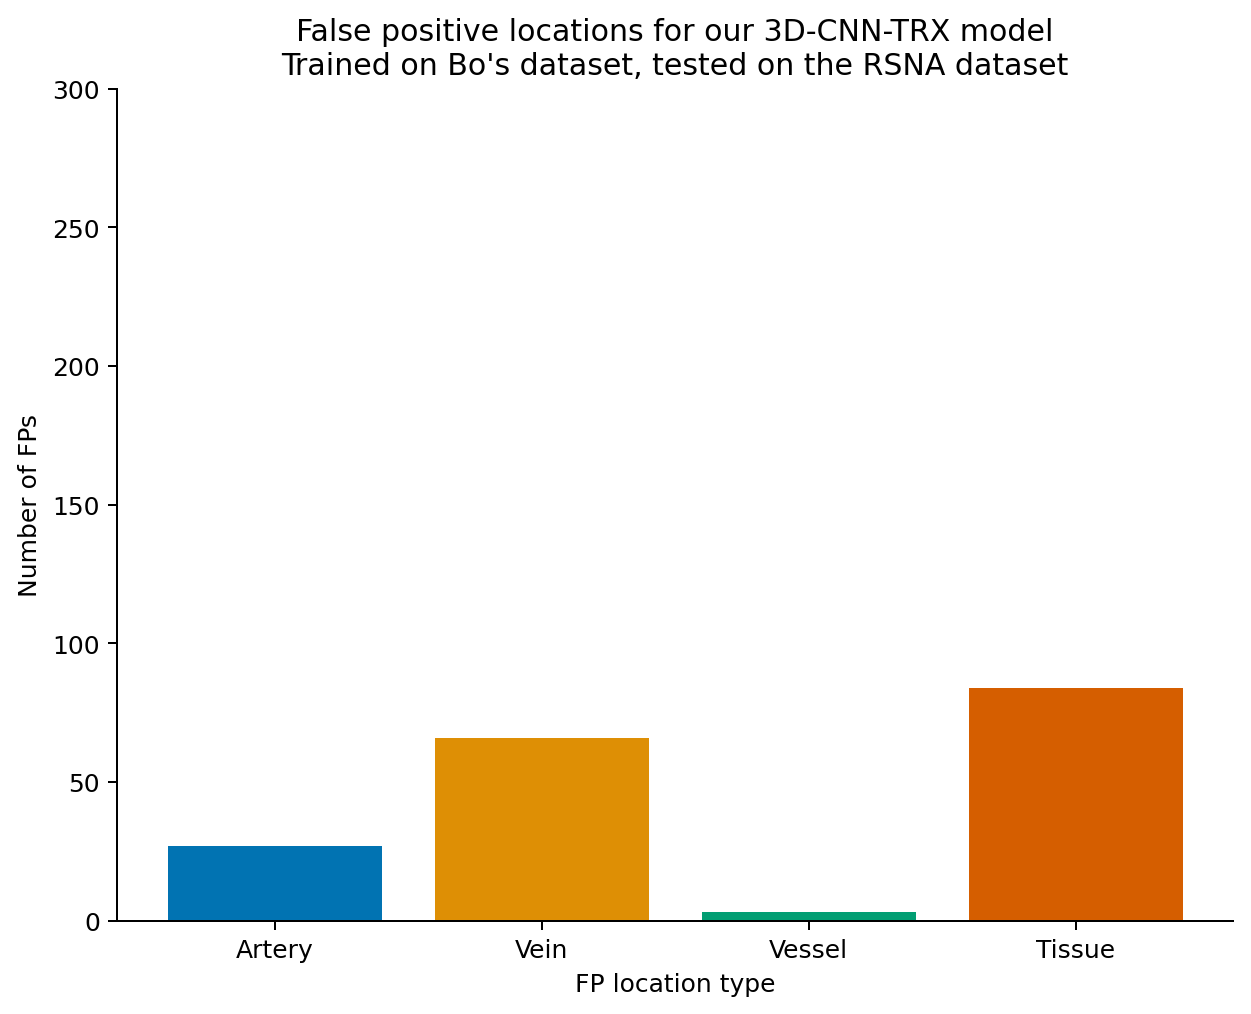

In [5]:
# draw bars  for location
location = [
    "Artery",
    "Vein",
    "Vessel",
    "Tissue",
]

vals_loc = [
    9*3,
    22*3,
    1*3,
    28*3
]

general_loc = ["Intracranial", "Extracranial"]

vals_gloc = [105, 77]
sns.set_palette("colorblind")

fig, ax = plt.subplots(figsize=(8, 6), dpi=180)
for i, loc in enumerate(location):
    ax.bar(loc, vals_loc[i])
ax.set_ylim(0, 300)
#remove g rid 
ax.grid(False, axis='x')
ax.grid(False, axis='y')

sns.despine(top=True, right=True)
ax.set_xlabel('FP location type')
ax.set_ylabel('Number of FPs')
ax.set_title('False positive locations for our 3D-CNN-TRX model\nTrained on Bo\'s dataset, tested on the RSNA dataset')
# remove top and right spines